In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind,ttest_rel
from sklearn.preprocessing import StandardScaler, MinMaxScaler

**Problem Statement**
Delhivery wants to analyse the data and to derive useful insights that help them advance the field as compared to their competetors. The analysis is to
* clean and manipulate the data to get useful feature out of the raw data.
* derive useful insights that helps the datascience team for building forecasting models
* creating new features that help improving the service.
* check the difference between the actual and predicted delivery metrices

## **`1. Loading Dataset`**

In [2]:
df=pd.read_csv('delhivery_data_business case data.txt')

In [3]:
df_cpy=df.copy()

## **`1. Basic Data Cleaning and Exploration`**

In [ ]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [ ]:
df.shape

(144867, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [ ]:
#finding the total null values in the dataframe
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


* There are 261 null values in destination_name column and 293 nulll values in source_name column.

In [ ]:
# Checking for the duplicated values
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [4]:
# Converting into the pd datetime format
df['trip_creation_time']=pd.to_datetime(df['trip_creation_time'])
df['od_start_time'] = pd.to_datetime(df['od_start_time'])
df['od_end_time'] = pd.to_datetime(df['od_end_time'])

## **`2. Exploratory Data Analysis`**

In [ ]:
df['data'].value_counts()

,count
data,
training,104858
test,40009


In [ ]:
df['route_type'].value_counts()

,count
route_type,
FTL,99660
Carting,45207


Text(0.5, 1.0, 'time distribution for different transportation type')

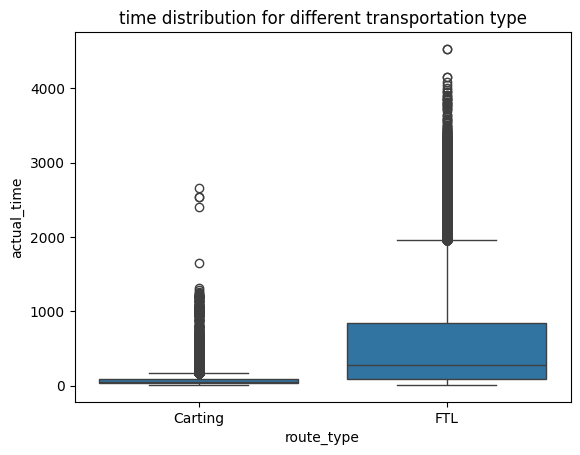

In [ ]:
sns.boxplot(x='route_type',y='actual_time',data=df)
plt.title('time distribution for different transportation type')


**Insight** : FTL is more preferred transportation as the total time is lesser there

<Axes: xlabel='osrm_time', ylabel='Count'>

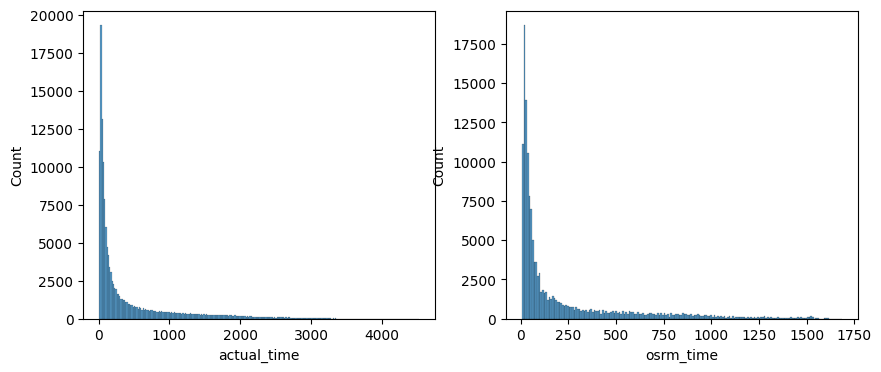

In [ ]:
plt.figure(figsize=(10,4)),
plt.subplot(1,2,1)
sns.histplot(df['actual_time'])
plt.subplot(1,2,2)
sns.histplot(df['osrm_time'])


<Axes: xlabel='osrm_distance', ylabel='Count'>

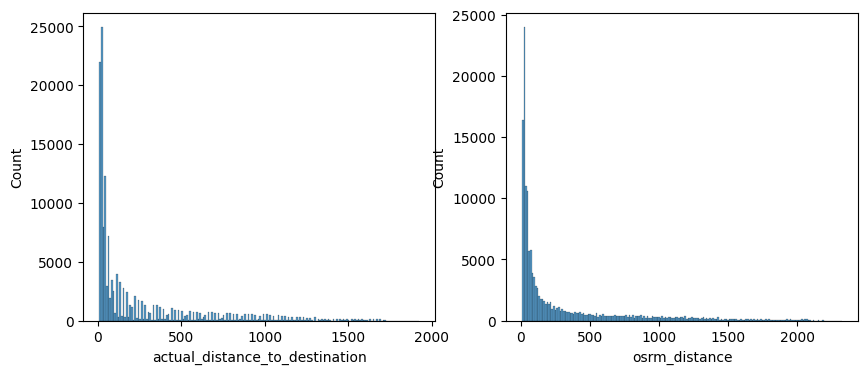

In [ ]:
plt.figure(figsize=(10,4)),
plt.subplot(1,2,1)
sns.histplot(df['actual_distance_to_destination'])
plt.subplot(1,2,2)
sns.histplot(df['osrm_distance'])


<Axes: xlabel='actual_distance_to_destination', ylabel='actual_time'>

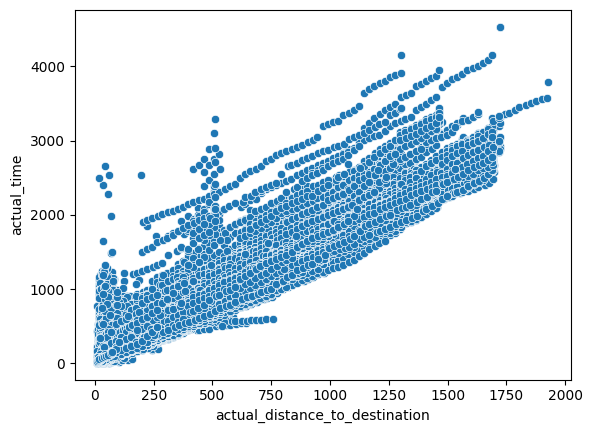

In [44]:
sns.scatterplot(x=df['actual_distance_to_destination'],y=df['actual_time'],data=df)

* As the distance increases time also increases
* A few deviations are also visible in the linear pattern

## **`2. Merging Rows`**

In [5]:
# creating a new column segment_key by merging trip_uuid, source_center, destination_center
df['segment_key']=df['trip_uuid']+'_'+df['source_center']+'_'+df['destination_center']
df['segment_key']

,segment_key
0,trip-153741093647649320_IND388121AAA_IND388620AAB
1,trip-153741093647649320_IND388121AAA_IND388620AAB
2,trip-153741093647649320_IND388121AAA_IND388620AAB
3,trip-153741093647649320_IND388121AAA_IND388620AAB
4,trip-153741093647649320_IND388121AAA_IND388620AAB
...,...
144862,trip-153746066843555182_IND131028AAB_IND000000ACB
144863,trip-153746066843555182_IND131028AAB_IND000000ACB
144864,trip-153746066843555182_IND131028AAB_IND000000ACB
144865,trip-153746066843555182_IND131028AAB_IND000000ACB


In [6]:
 # Grouping on the numerical columns by the segment_key
df['segment_actual_time_sum']=df.groupby('segment_key')['actual_time'].cumsum()
df['segment_osrm_time_sum']=df.groupby('segment_key')['osrm_time'].cumsum()
df['segment_osrm_distance_sum']=df.groupby('segment_key')['osrm_distance'].cumsum()
df[['segment_actual_time_sum','segment_osrm_time_sum','segment_osrm_distance_sum']]

,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,14.0,11.0,11.9653
1,38.0,31.0,33.6896
2,78.0,59.0,66.2291
3,140.0,99.0,111.7911
4,208.0,143.0,166.0092
...,...,...,...
144862,345.0,230.0,228.5453
144863,465.0,306.0,314.2282
144864,605.0,394.0,411.3215
144865,763.0,492.0,522.5924


In [7]:
# Creating dictionary for aggreation on numerical columns
create_segment_dict={'trip_uuid':'first','od_start_time':'first','od_end_time':'last','actual_time':'sum','osrm_time':'sum','osrm_distance':'sum','segment_actual_time':'sum','segment_osrm_time':'sum','segment_osrm_distance':'sum'}

In [8]:
# Aggregation based on the segment_key
segment_base_agg=df.groupby('segment_key').agg(create_segment_dict).sort_values('segment_key',ascending=True)
segment_base_agg.sort_values('od_end_time',ascending=True)

,trip_uuid,od_start_time,od_end_time,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
segment_key,,,,,,,,,
trip-153671110078355292_IND121004AAB_IND121001AAA,trip-153671110078355292,2018-09-12 00:11:40.783923,2018-09-12 00:50:10.814399,17.0,9.0,10.8159,17.0,9.0,10.8159
trip-153671079956500691_IND110024AAA_IND110014AAA,trip-153671079956500691,2018-09-12 00:06:39.565253,2018-09-12 00:55:59.568645,35.0,16.0,19.9606,23.0,14.0,16.0860
trip-153671066826362165_IND560043AAC_IND560064AAA,trip-153671066826362165,2018-09-12 00:04:28.263977,2018-09-12 01:13:03.560690,50.0,36.0,27.6866,25.0,18.0,13.8433
trip-153671173668736946_IND110043AAA_IND110078AAA,trip-153671173668736946,2018-09-12 00:22:16.687619,2018-09-12 01:29:19.277412,72.0,42.0,37.2326,43.0,25.0,22.6548
trip-153671277074687197_IND624001AAA_IND624619AAA,trip-153671277074687197,2018-09-12 00:39:30.747127,2018-09-12 01:32:05.649177,64.0,48.0,51.3800,40.0,26.0,27.8572
...,...,...,...,...,...,...,...,...,...
trip-153859003271955591_IND000000ACB_IND562132AAA,trip-153859003271955591,2018-10-04 05:27:22.883248,2018-10-06 11:08:18.498393,107774.0,60709.0,79759.7761,2917.0,1860.0,2424.6878
trip-153840656812932039_IND712311AAA_IND421302AAG,trip-153840656812932039,2018-10-03 21:21:11.054680,2018-10-06 19:28:24.500705,120992.0,51677.0,72491.2403,3338.0,1431.0,2068.1202
trip-153858876340944305_IND000000ACB_IND562132AAA,trip-153858876340944305,2018-10-03 17:46:03.409692,2018-10-06 19:46:59.723686,167920.0,60504.0,79458.9058,4122.0,1706.0,2242.9029


## **`3.Feature Engineering`**

In [9]:
# Creating new feature 'od_time_diff_hour' from 'od_start_time' and 'od_end_time'
df['od_time_diff_hour']=(df['od_end_time']-df['od_start_time']).dt.total_seconds()/3600
df.drop(['od_end_time','od_start_time'],axis=1,inplace=True)
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,start_scan_to_end_scan,...,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,segment_key,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,od_time_diff_hour
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,1.272727,14.0,11.0,11.9653,1.272727,trip-153741093647649320_IND388121AAA_IND388620AAB,14.0,11.0,11.9653,1.436894
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,1.200000,10.0,9.0,9.7590,1.111111,trip-153741093647649320_IND388121AAA_IND388620AAB,38.0,31.0,33.6896,1.436894
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,1.428571,16.0,7.0,10.8152,2.285714,trip-153741093647649320_IND388121AAA_IND388620AAB,78.0,59.0,66.2291,1.436894
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,1.550000,21.0,12.0,13.0224,1.750000,trip-153741093647649320_IND388121AAA_IND388620AAB,140.0,99.0,111.7911,1.436894
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,1.545455,6.0,5.0,3.9153,1.200000,trip-153741093647649320_IND388121AAA_IND388620AAB,208.0,143.0,166.0092,1.436894


In [70]:
# time difference between the actual time taken and the predicted time for each trip
df['tim_diff'] = df['actual_time'] - df['osrm_time']
df['tim_diff'].describe()

,tim_diff
count,144867.000000
mean,203.059254
std,303.743664
min,-110.000000
25%,21.000000
50%,65.000000
75%,247.000000
max,3137.000000


* Mean time difference between the actual time and predicted time is 203.
* It tells that the actual time taken is more than the predicted time quite often

Text(0.5, 0, 'time_difference in minutes')

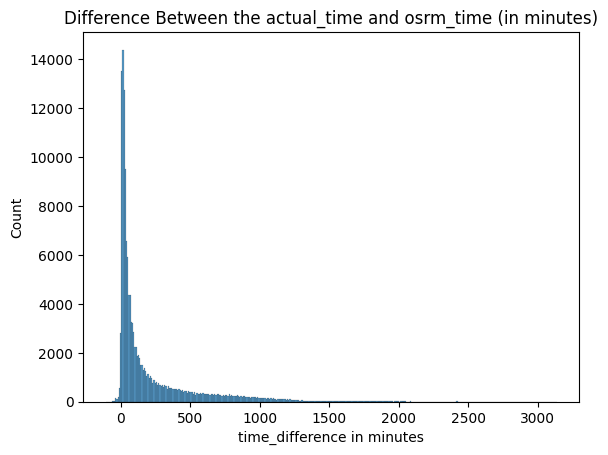

In [76]:
sns.histplot(df['tim_diff'])
plt.title('Difference Between the actual_time and osrm_time (in minutes)')
plt.xlabel('time_difference in minutes')

* There is difference between the actual time and predicted time. Only a few deliveries are happening before time

In [11]:
# Splitting and extracting features out of the source_name
df[['source_city','source_place','source_code']]=df['source_name'].str.split('_',n=2,expand=True)
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,start_scan_to_end_scan,...,segment_factor,segment_key,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,od_time_diff_hour,tim_diff,source_city,source_place,source_code
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,1.272727,trip-153741093647649320_IND388121AAA_IND388620AAB,14.0,11.0,11.9653,1.436894,3.0,Anand,VUNagar,DC (Gujarat)
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,1.111111,trip-153741093647649320_IND388121AAA_IND388620AAB,38.0,31.0,33.6896,1.436894,4.0,Anand,VUNagar,DC (Gujarat)
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,2.285714,trip-153741093647649320_IND388121AAA_IND388620AAB,78.0,59.0,66.2291,1.436894,12.0,Anand,VUNagar,DC (Gujarat)
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,1.750000,trip-153741093647649320_IND388121AAA_IND388620AAB,140.0,99.0,111.7911,1.436894,22.0,Anand,VUNagar,DC (Gujarat)
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,1.200000,trip-153741093647649320_IND388121AAA_IND388620AAB,208.0,143.0,166.0092,1.436894,24.0,Anand,VUNagar,DC (Gujarat)


In [12]:
# finding the state where the most number of orders are coming from
source_statewise_order=df.groupby('source_code')['trip_uuid'].count().sort_values(ascending=False)
source_statewise_order.head()

,trip_uuid
source_code,
HB (Haryana),23347
H (Karnataka),10061
HB (Maharashtra),9088
H (Maharashtra),4064
D (Uttar Pradesh),3415


* Most number of orders are coming from Haryana.
* Nearly considerable number of order are shipped from boht Karnataka and Maharashtra

In [13]:
# Extracting features out of the destination_name
df[['destination_city','destination_place','destination_code']]=df['destination_name'].str.split('_',n=2,expand=True)
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,start_scan_to_end_scan,...,segment_osrm_time_sum,segment_osrm_distance_sum,od_time_diff_hour,tim_diff,source_city,source_place,source_code,destination_city,destination_place,destination_code
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,11.0,11.9653,1.436894,3.0,Anand,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat)
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,31.0,33.6896,1.436894,4.0,Anand,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat)
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,59.0,66.2291,1.436894,12.0,Anand,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat)
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,99.0,111.7911,1.436894,22.0,Anand,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat)
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,143.0,166.0092,1.436894,24.0,Anand,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat)


In [14]:
# finding the destination wise orders, where to the maximum number of orders are delivered
destination_statewisea_order=df.groupby('destination_code')['trip_uuid'].count().sort_values(ascending=False)
destination_statewisea_order.head()

,trip_uuid
destination_code,
HB (Haryana),15192
H (Karnataka),11274
HB (Maharashtra),5492
H (Telangana),5142
HB (West Bengal),4892


* Most number of orders are also delivered to Haryana and then Karnataka

In [15]:
# creating a new feature corridor with source code and destination code
df['corridor'] = df['source_code'] + '->' + df['destination_code']

Text(0, 0.5, 'Average time Taken for Transportation')

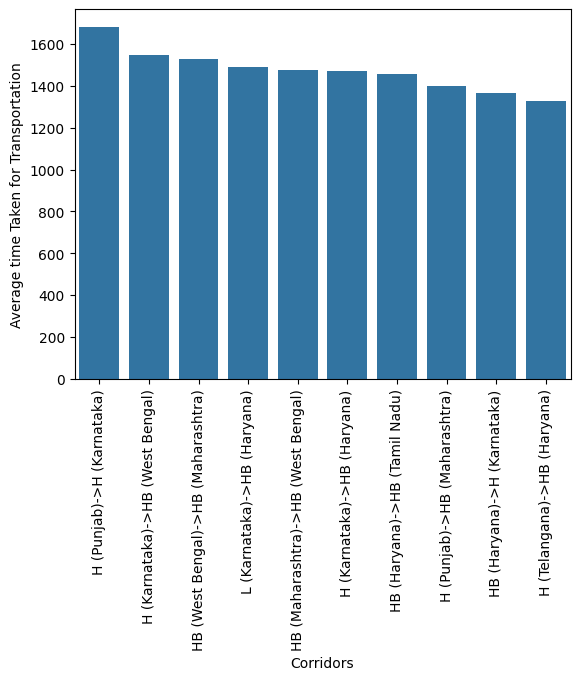

In [65]:
corridorwise_time=df.groupby('corridor')['actual_time'].mean().sort_values(ascending=False)
sns.barplot(x=corridorwise_time.head(10).index,y=corridorwise_time.head(10).values)
plt.xticks(rotation=90)
plt.xlabel('Corridors')
plt.ylabel('Average time Taken for Transportation')

* Average time for tranportation is more for the corridor Punjab to Karnataka

In [16]:
# finding the busiest corridor
corridorwise_orders = df.groupby('corridor')['trip_uuid'].count().sort_values(ascending=False)
corridorwise_orders.head()

,trip_uuid
corridor,
HB (Haryana)->H (Karnataka),4976
H (Karnataka)->HB (Haryana),3316
HB (Haryana)->HB (West Bengal),2862
D (Tamil Nadu)->D (Tamil Nadu),1846
D (Karnataka)->D (Karnataka),1682


* Largest number of transportation happens from Haryana to Karnataka, seems to be the busiest one.
* Karnataka to Haryana is the next busiest one.

Text(0, 0.5, 'No of orders')

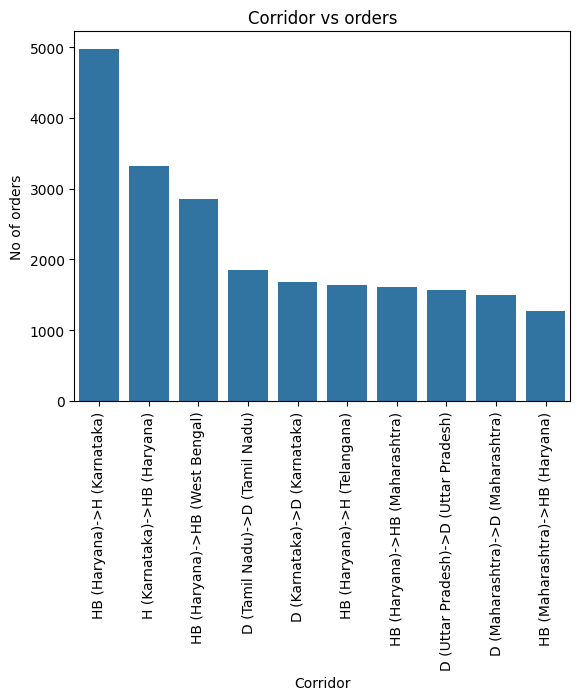

In [58]:
sns.barplot(x=corridorwise_orders.head(10).index,y=corridorwise_orders.head(10).values)
plt.xticks(rotation=90)
plt.title('Corridor vs orders')
plt.xlabel('Corridor')
plt.ylabel('No of orders')

In [17]:
df['city_to_city'] = df['source_city'] + '->' + df['destination_city']

In [18]:
city_to_city_routes = df.groupby('city_to_city')['trip_uuid'].agg('count')

In [ ]:
city_to_city_routes.head()

,trip_uuid
city_to_city,
Gurgaon->Bangalore,4976
Bangalore->Gurgaon,3316
Gurgaon->Kolkata,2862
Bengaluru->Bengaluru,2062
Bangalore->Bengaluru,1741


* Busiest transportation route between cities is from Guragon to Banglore, then backwards

In [19]:
# distance for different corridors
source_to_destination_distance=df.groupby('corridor')['actual_distance_to_destination'].mean().sort_values(ascending=False)
source_to_destination_distance.head()

,actual_distance_to_destination
corridor,
H (Punjab)->H (Karnataka),1050.751668
HB (Haryana)->HB (Tamil Nadu),876.628008
L (Karnataka)->HB (Haryana),870.118858
H (Karnataka)->HB (Haryana),869.072245
HB (Haryana)->H (Karnataka),859.827666


* Punjab to Karnataka is the longest transporation route

In [20]:
# Finding the time for each corridor
source_to_destination_time=df.groupby('corridor')['actual_time'].mean().sort_values(ascending=False)
source_to_destination_time.head()

,actual_time
corridor,
H (Punjab)->H (Karnataka),1682.728395
H (Karnataka)->HB (West Bengal),1549.171296
HB (West Bengal)->HB (Maharashtra),1531.104278
L (Karnataka)->HB (Haryana),1489.641026
HB (Maharashtra)->HB (West Bengal),1477.367316


In [21]:
# Extracting features out of the trip_creation_time
df['trip_creation_year'] = df['trip_creation_time'].dt.year
df['trip_creation_month'] = df['trip_creation_time'].dt.month
df['trip_creation_day'] = df['trip_creation_time'].dt.day
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,start_scan_to_end_scan,...,source_place,source_code,destination_city,destination_place,destination_code,corridor,city_to_city,trip_creation_year,trip_creation_month,trip_creation_day
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat),DC (Gujarat)->D (Gujarat),Anand->Khambhat,2018,9,20
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat),DC (Gujarat)->D (Gujarat),Anand->Khambhat,2018,9,20
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat),DC (Gujarat)->D (Gujarat),Anand->Khambhat,2018,9,20
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat),DC (Gujarat)->D (Gujarat),Anand->Khambhat,2018,9,20
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,...,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat),DC (Gujarat)->D (Gujarat),Anand->Khambhat,2018,9,20


## **`4.In-depth Analysis`**

In [22]:
# Creating the dictionaries for trip base data with suitable aggregation functions
create_trip_dict={'trip_uuid':'first','od_time_diff_hour':'sum','actual_distance_to_destination':'sum','actual_time':'last','osrm_time':'sum','osrm_distance':'sum','segment_actual_time':'sum','segment_osrm_time':'sum','segment_osrm_distance':'sum'}

In [23]:
# Aggregating the numerical columns based on the trip_uuid
trip_base_agg=df.groupby('trip_uuid').agg(create_trip_dict)
trip_base_agg

,trip_uuid,od_time_diff_hour,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
trip_uuid,,,,,,,,,
trip-153671041653548748,trip-153671041653548748,728.008209,8860.812105,732.0,7787.0,10577.7647,1548.0,1008.0,1320.4733
trip-153671042288605164,trip-153671042288605164,15.219568,240.208306,47.0,210.0,269.4308,141.0,65.0,84.1894
trip-153671043369099517,trip-153671043369099517,4144.906395,68163.502238,611.0,65768.0,89447.2488,3308.0,1941.0,2545.2678
trip-153671046011330457,trip-153671046011330457,3.349831,28.529648,59.0,24.0,31.6475,59.0,16.0,19.8766
trip-153671052974046625,trip-153671052974046625,26.478517,239.007304,131.0,207.0,266.2914,340.0,115.0,146.7919
...,...,...,...,...,...,...,...,...,...
trip-153861095625827784,trip-153861095625827784,14.655464,141.057373,49.0,148.0,162.9473,82.0,62.0,64.8551
trip-153861104386292051,trip-153861104386292051,2.019684,25.130640,21.0,19.0,26.5333,21.0,11.0,16.0883
trip-153861106442901555,trip-153861106442901555,21.105993,93.743842,190.0,134.0,162.8499,281.0,88.0,104.8866


In [24]:
# creating a function for outlier detection
def outlier_removal(df_demo,column):
  Q1=df_demo[column].quantile(0.25)
  Q3=df_demo[column].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-(1.5*IQR)
  upper=Q3+(1.5*IQR)

  return df_demo[(df_demo[column]>=lower)&(df_demo[column]<=upper)]

In [25]:
#removing outliers from the aggregated dataframe and storing it to a new dataframe
column=['od_time_diff_hour','actual_time','osrm_time','actual_distance_to_destination','osrm_distance','segment_actual_time','segment_osrm_distance','segment_osrm_time']
trip_base_agg_cpy=trip_base_agg.copy()
for col in column:
  trip_base_agg_cpy=outlier_removal(trip_base_agg_cpy,col)


# The hypothesis testing can be done on the newly created dataset trip_base_agg_cpy where the outlier removal was done.

In [26]:
# Applying one hot encoding for the categorical variables
df = pd.get_dummies(df,columns=['route_type'],drop_first=True)

In [ ]:
df.head()

,data,trip_creation_time,route_schedule_uuid,trip_uuid,source_center,source_name,destination_center,destination_name,start_scan_to_end_scan,is_cutoff,...,source_place,source_code,destination_city,destination_place,destination_code,corridor,trip_creation_year,trip_creation_month,trip_creation_day,route_type_FTL
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,True,...,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat),DC (Gujarat)->D (Gujarat),2018,9,20,False
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,True,...,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat),DC (Gujarat)->D (Gujarat),2018,9,20,False
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,True,...,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat),DC (Gujarat)->D (Gujarat),2018,9,20,False
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,True,...,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat),DC (Gujarat)->D (Gujarat),2018,9,20,False
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),86.0,False,...,VUNagar,DC (Gujarat),Khambhat,MotvdDPP,D (Gujarat),DC (Gujarat)->D (Gujarat),2018,9,20,False


## **`6. Visualization on outliers`**

In [ ]:
# comparing the outliers before and after outlier removal from the trip base aggregated dataset

In [ ]:
#column=['od_time_diff_hour','actual_time','osrm_time','actual_distance_to_destination','osrm_distance','segment_actual_time','segment_osrm_distance','segment_osrm_time']

Text(0.5, 1.0, 'after_outlier_removal')

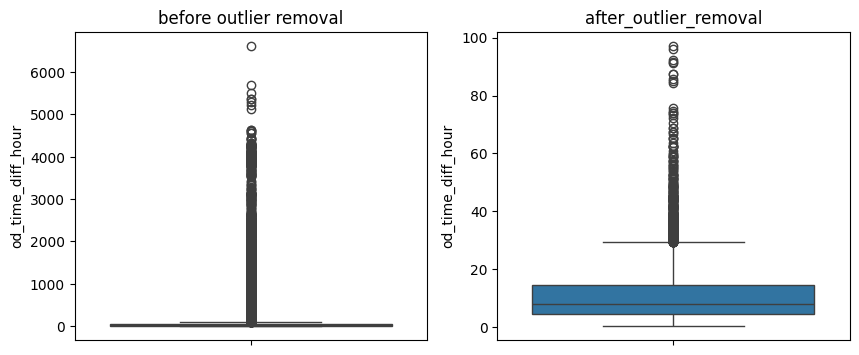

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(trip_base_agg['od_time_diff_hour'])
plt.title('before outlier removal')
plt.subplot(1,2,2)
sns.boxplot(trip_base_agg_cpy['od_time_diff_hour'])
plt.title('after_outlier_removal')

Text(0.5, 1.0, 'after_outlier_removal')

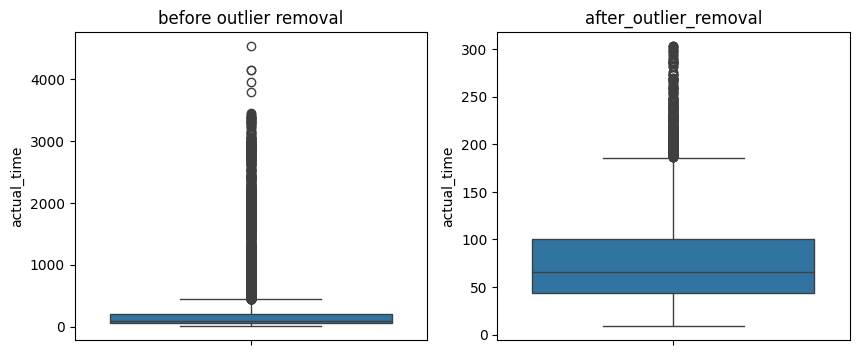

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(trip_base_agg['actual_time'])
plt.title('before outlier removal')
plt.subplot(1,2,2)
sns.boxplot(trip_base_agg_cpy['actual_time'])
plt.title('after_outlier_removal')

Text(0.5, 1.0, 'after_outlier_removal')

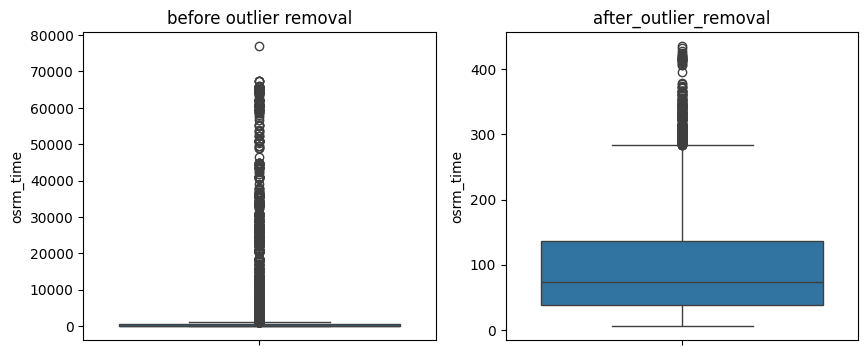

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(trip_base_agg['osrm_time'])
plt.title('before outlier removal')
plt.subplot(1,2,2)
sns.boxplot(trip_base_agg_cpy['osrm_time'])
plt.title('after_outlier_removal')

Text(0.5, 1.0, 'after_outlier_removal')

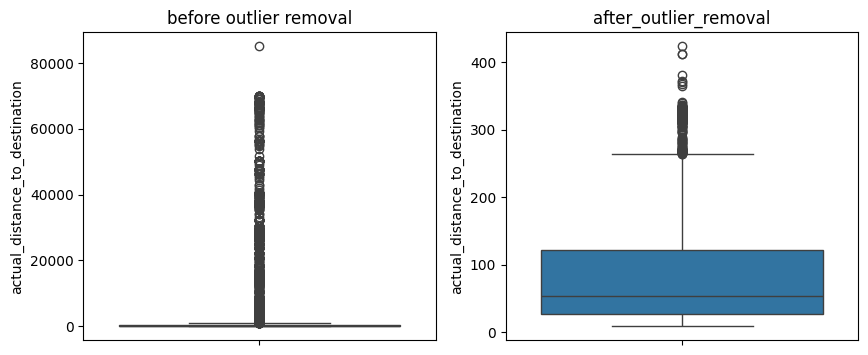

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(trip_base_agg['actual_distance_to_destination'])
plt.title('before outlier removal')
plt.subplot(1,2,2)
sns.boxplot(trip_base_agg_cpy['actual_distance_to_destination'])
plt.title('after_outlier_removal')

Text(0.5, 1.0, 'after_outlier_removal')

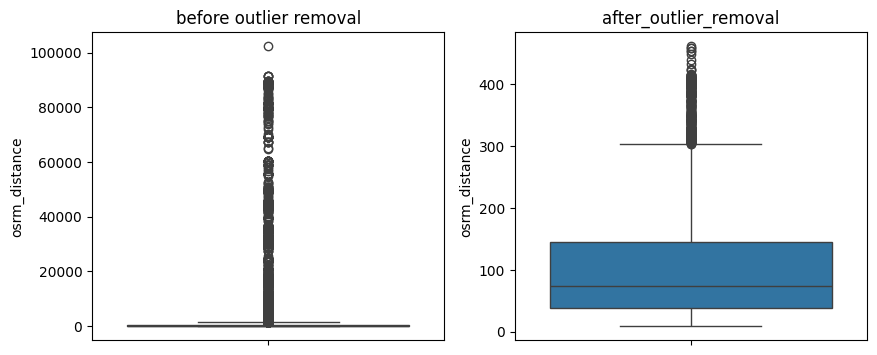

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(trip_base_agg['osrm_distance'])
plt.title('before outlier removal')
plt.subplot(1,2,2)
sns.boxplot(trip_base_agg_cpy['osrm_distance'])
plt.title('after_outlier_removal')

Text(0.5, 1.0, 'after_outlier_removal')

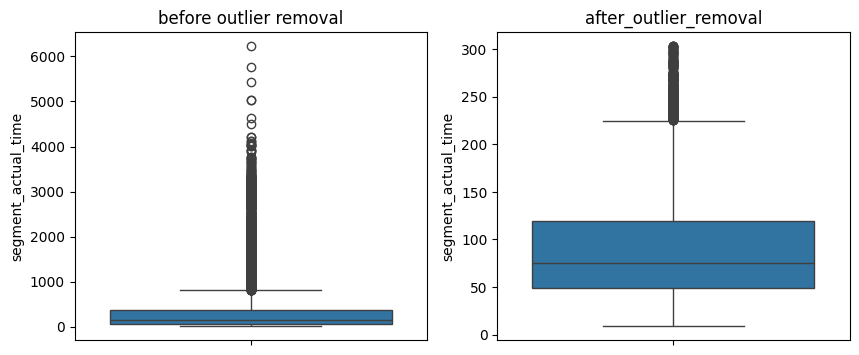

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(trip_base_agg['segment_actual_time'])
plt.title('before outlier removal')
plt.subplot(1,2,2)
sns.boxplot(trip_base_agg_cpy['segment_actual_time'])
plt.title('after_outlier_removal')

Text(0.5, 1.0, 'after_outlier_removal')

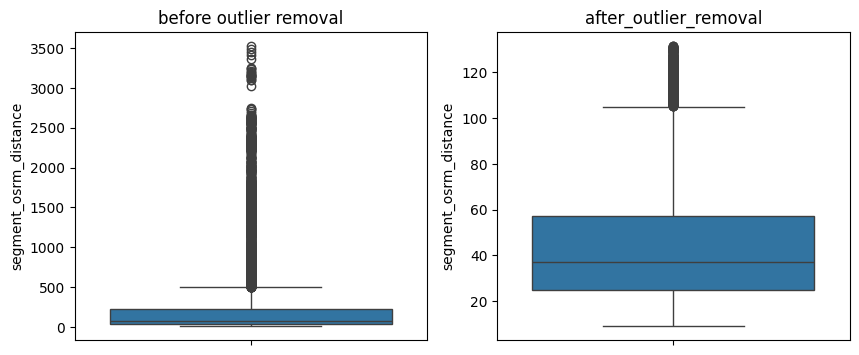

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(trip_base_agg['segment_osrm_distance'])
plt.title('before outlier removal')
plt.subplot(1,2,2)
sns.boxplot(trip_base_agg_cpy['segment_osrm_distance'])
plt.title('after_outlier_removal')

Text(0.5, 1.0, 'after_outlier_removal')

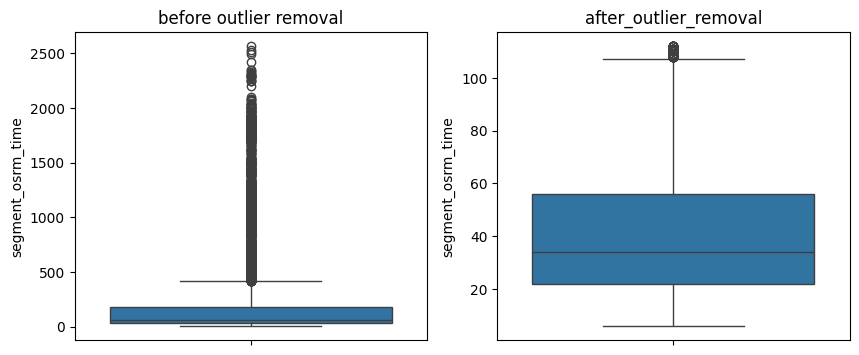

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(trip_base_agg['segment_osrm_time'])
plt.title('before outlier removal')
plt.subplot(1,2,2)
sns.boxplot(trip_base_agg_cpy['segment_osrm_time'])
plt.title('after_outlier_removal')

In [28]:
# Correlation and heat map for the numerical columns before and after the outlier removal
df[column].corr()

,od_time_diff_hour,actual_time,osrm_time,actual_distance_to_destination,osrm_distance,segment_actual_time,segment_osrm_distance,segment_osrm_time
od_time_diff_hour,1.000000,0.785936,0.785298,0.785005,0.784137,0.093302,0.306980,0.219846
actual_time,0.785936,1.000000,0.977998,0.978659,0.979399,0.124411,0.242282,0.171465
osrm_time,0.785298,0.977998,1.000000,0.995872,0.999119,0.049892,0.242282,0.177066
actual_distance_to_destination,0.785005,0.978659,0.995872,1.000000,0.997149,0.045241,0.232119,0.158832
osrm_distance,0.784137,0.979399,0.999119,0.997149,1.000000,0.048705,0.239669,0.169151
segment_actual_time,0.093302,0.124411,0.049892,0.045241,0.048705,1.000000,0.448959,0.433422
segment_osrm_distance,0.306980,0.242282,0.242282,0.232119,0.239669,0.448959,1.000000,0.948523
segment_osrm_time,0.219846,0.171465,0.177066,0.158832,0.169151,0.433422,0.948523,1.000000


Text(0.5, 1.0, 'correlation before the outlier removal')

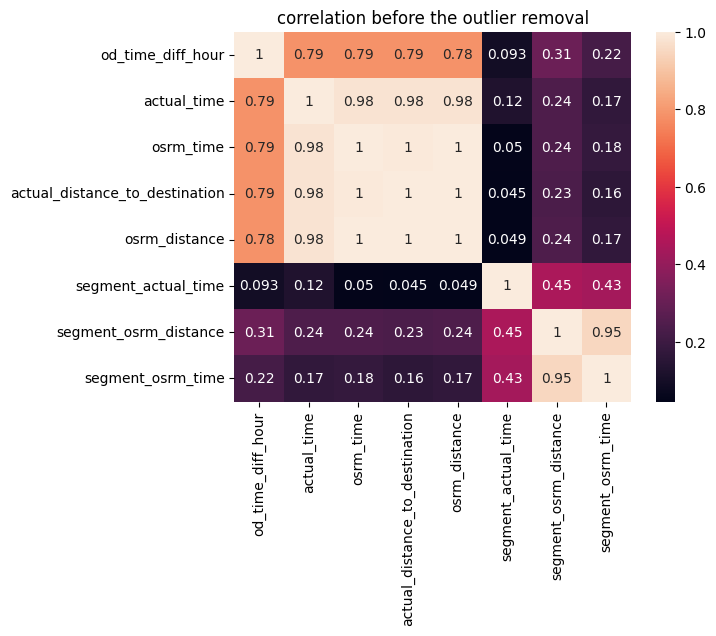

In [36]:
sns.heatmap(df[column].corr(),annot=True)
plt.title('correlation before the outlier removal')

Text(0.5, 1.0, 'After Outliers removal')

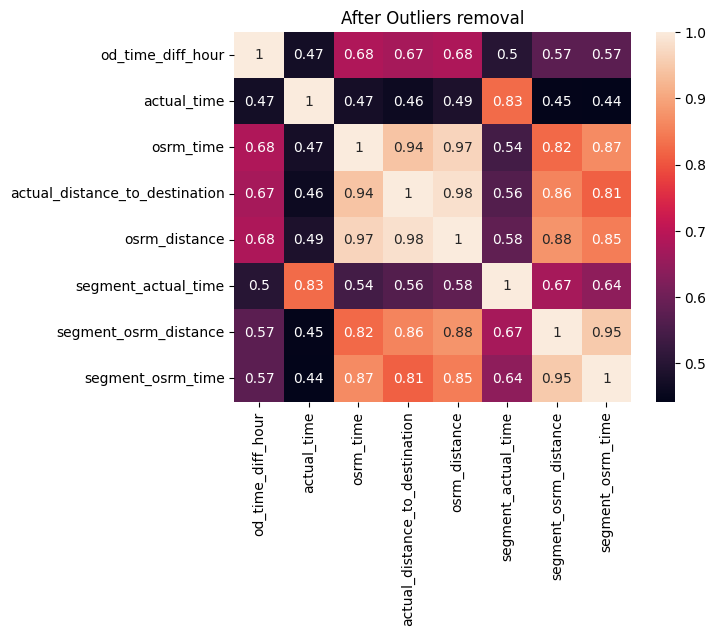

In [37]:
sns.heatmap(trip_base_agg_cpy[column].corr(),annot=True)
plt.title('After Outliers removal')

* Transportion time and distance are in strong positive correlation. The transportion time increases as the distance inreases
* The actual time and the predicted time are only weakly related.


## **`5. Hypothesis Testing`**

 **`1.`** actual_time aggregated value vs OSRM time aggregated value.

 Is the actual time taken by the trip lesser than the predicted time?

 * H0: There is no difference between the actual_time and osrm_time
*  Ha: actual time different the predicted time

signicance level 5%

In [68]:
ttest_rel(trip_base_agg_cpy['actual_time'],trip_base_agg_cpy['osrm_time'])

TtestResult(statistic=np.float64(-26.350368447580458), pvalue=np.float64(2.625235905137636e-147), df=np.int64(8729))

Conclusions:
*  pvalue<significance level
* Null hypothesis is rejected
* Actual and osrm predicted time are different

**2.** actual_time aggregated value and segment actual time aggregated value.

Is the actual time aggregated and segment actual time aggregated values are same or not?

* H0: Actual time aggregated and segment actual time aggregated values are the same
* Ha : Actual time aggregated and segment actual time aggregated values are not the same
Significance level 5%

In [ ]:
ttest_rel(trip_base_agg_cpy['actual_time'],trip_base_agg_cpy['segment_actual_time'])

TtestResult(statistic=np.float64(-35.66091843880159), pvalue=np.float64(3.85097858257603e-260), df=np.int64(8729))

Conclusions:
*  pvalue<significance level
* Null hypothesis is rejected
* Actual and osrm segment actual time aggregated are different

**3.** OSRMdistance aggregated value and segment OSRM distance aggregated value.

Is ther any significant difference between osrm distance aggregated value and segment osrm distance aggregated value

* H0: osrm distance aggregated value and segment osrm distance aggregated value same

* Ha: osrm distance aggregated value and segment osrm distance aggregated value are different

In [ ]:
ttest_rel(trip_base_agg_cpy['osrm_distance'],trip_base_agg_cpy['segment_osrm_distance'])

TtestResult(statistic=np.float64(93.28087341975727), pvalue=np.float64(0.0), df=np.int64(8729))

Conclusions:
*  pvalue<significance level
* Null hypothesis is rejected
* osrm distance and segment osrm predicted distance are different

**4.** OSRMtimeaggregated value and segment OSRM time aggregated
value.

* Ha: osrm time aggregated and segment osrm time aggregated are the same
* Ha: osrm time aggregated and segment osrm time aggregated are not the same

significance level 5%

In [ ]:
ttest_rel(trip_base_agg_cpy['osrm_time'],trip_base_agg_cpy['segment_osrm_time'])

TtestResult(statistic=np.float64(94.59804615974909), pvalue=np.float64(0.0), df=np.int64(8729))

Conclusions:
*  pvalue<significance level
* Null hypothesis is rejected
* osrm time and segment aggregated osrm time are different

## **`7. Feature Scaling`**

In [ ]:
scaler=StandardScaler()
column=['od_time_diff_hour','actual_time','osrm_time','actual_distance_to_destination','osrm_distance','segment_actual_time','segment_osrm_distance','segment_osrm_time']
for col in column:
  trip_base_agg_cpy[col] = scaler.fit_transform(trip_base_agg_cpy[[col]])

* Applied feature scaling to the numerical columns in the aggregated data sate based on the trip_uuid

## **`8. Business Recommendations`**

* Delivery time:
  * The actual time taken during transport and predicted time are not the same. So the model for predicting the time can be made better for more accurate prediction
  * Difference between Actual time and predicted time is positive which tells, delivery of orders happens delayed than the expected time.
  * Delay in the actual transport time can be reduced by reducing the expected delays and choosing the less traffic routes
*Route type:
  * As the full truck load type takes the lowest time when compared to carting method, more transportation can be done through this method
  * More orders can be shipped to the destination hub through busiest routes where more trucks are available
  * Tracking alerts can be given for better monitoring
* Source and destination hubs can be expanded to more tier2 and tier 3 cities where the demand is higher
*  HB (Haryana)->H (Karnataka) is the busiest route. Increasing truck allocation in this route can reduce the delays.
* Average time for tranportation is more for the corridor Punjab to Karnataka. This is longer route. Intermediate hubs can be introduced for longer routes to reduce the transporation time. Better routes (like express highways) can be selected for the transportation.
* loading and unloading time should be optimised